# GP-GLLVM exact round-trip: ε ↔ Z and Gaussian encoder sanity check

Two tests, no approximations:

1. **Exact ε → Z → ε**: forward map $z = L_\Sigma\varepsilon$ and its exact inverse
   $\varepsilon = L_\Sigma^{-1}z$ — should recover $\varepsilon$ to machine precision.

2. **Gaussian round-trip**: $\varepsilon \to z \to y\sim N(Wz+b,\sigma^2 I) \to \hat z \to \hat\varepsilon$.
   With Gaussian observations the block MAP $\hat z$ is the **exact posterior mean** (conjugate model,
   no proxy) — so recovery should be limited only by the noise level $\sigma$.


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from collections import namedtuple

torch.set_default_dtype(torch.float64)
DEV = "cpu"

Q, P     = 2, 20          # latent dim, responses
K        = 15             # timepoints per block
N        = 500            # number of independent groups
ELL      = [1.0, 4.0]    # distinct per-latent lengthscales
RHO      = 0.7            # cross-latent correlation
SIGMA    = 0.5            # Gaussian observation noise std
WZS      = 0.7            # loading scale
JIT      = 1e-4

t = (torch.arange(K) * 0.2).to(DEV)     # timepoints in [0, 2.8]
print(f"Q={Q}, P={P}, K={K}, N={N}, ell={ELL}, rho={RHO}, sigma={SIGMA}")


Q=2, P=20, K=15, N=500, ell=[1.0, 4.0], rho=0.7, sigma=0.5


## Core: exact maps ε ↔ Z and Gaussian encoder

`Params` bundles all model parameters.  `z_from_eps` and `eps_from_z` are
**exact** (Cholesky multiply / triangular solve) — no approximation.
`encode_gauss_exact` is the **exact posterior mean** of $Z$ given Gaussian $Y$
(conjugate model: no `log1p`, no proxy).


In [2]:
Params = namedtuple('Params', ['W', 'b', 'ells', 'B', 'ts'])

# ── covariance ────────────────────────────────────────────────────────────────

def build_Sigma(ts, ells, B):
    d2 = (ts[:,None] - ts[None,:]) ** 2
    rows = []
    for k in range(Q):
        row = []
        for l in range(Q):
            if k == l:
                row.append(torch.exp(-0.5 * d2 / ells[k]**2))
            else:
                lx2 = 0.5 * (ells[k]**2 + ells[l]**2)
                amp = (2.0*ells[k]*ells[l] / (ells[k]**2+ells[l]**2))**0.5
                row.append(B[k,l] * amp * torch.exp(-0.5*d2/lx2))
        rows.append(torch.cat(row, 1))
    S = torch.cat(rows, 0)
    return S + JIT * torch.eye(Q*len(ts), device=ts.device)

def vec(Z):       return Z.transpose(1,2).reshape(Z.shape[0],-1)   # (n,K,Q)->(n,QK) latent-major
def unvec(u, K):  return u.reshape(u.shape[0], Q, K).transpose(1,2) # (n,QK)->(n,K,Q)

def _chol(params):
    return torch.linalg.cholesky(build_Sigma(params.ts, params.ells, params.B))

# ── exact forward and inverse ─────────────────────────────────────────────────

def z_from_eps(eps, params):
    """Exact: ε (n,K,Q) → z (n,K,Q) via z_v = L_Σ ε_v."""
    L = _chol(params)
    return unvec(vec(eps) @ L.T, len(params.ts))

def eps_from_z(z, params):
    """Exact inverse: z (n,K,Q) → ε (n,K,Q) via ε_v = L_Σ⁻¹ z_v."""
    L = _chol(params)
    return unvec(torch.linalg.solve_triangular(L, vec(z).T, upper=False).T, len(params.ts))

# ── Gaussian model ────────────────────────────────────────────────────────────

def sample_y_gauss(z, params, sigma=SIGMA):
    """Y = ZWᵀ + b + N(0,σ²I) — exact Gaussian observations."""
    eta = torch.einsum('nkq,pq->nkp', z, params.W) + params.b
    return eta + sigma * torch.randn_like(eta)

def encode_gauss_exact(y, params, sigma2=SIGMA**2):
    """Exact Gaussian block MAP (= exact posterior mean, conjugate model).

    Posterior precision: A = Σ⁻¹ + kron(WᵀW/σ², I_K)
    Posterior mean:      vec(Z) = A⁻¹ vec((y−b)@W/σ²)

    No log1p, no proxy — y enters directly.  y: (n,K,P) → (z, ε) each (n,K,Q).
    """
    n, K, _ = y.shape
    T   = y - params.b                                           # (n,K,P) — exact
    rhs = vec(T @ params.W / sigma2)                             # (n,QK)

    L   = _chol(params)
    IQK = torch.eye(Q*K, dtype=params.W.dtype, device=params.W.device)
    IK  = torch.eye(K,   dtype=params.W.dtype, device=params.W.device)

    Lit     = torch.linalg.solve_triangular(L, IQK, upper=False) # L⁻¹
    Sig_inv = Lit.T @ Lit                                         # Σ⁻¹
    D       = torch.kron(params.W.T @ params.W / sigma2, IK)     # data precision
    LA      = torch.linalg.cholesky(Sig_inv + D)                 # factor once

    tmp   = torch.linalg.solve_triangular(LA,   rhs.T, upper=False)
    z_vec = torch.linalg.solve_triangular(LA.T, tmp,   upper=True).T  # (n,QK)

    z   = unvec(z_vec, K)
    eps = unvec((Lit @ z_vec.T).T, K)
    return z, eps


## Fix true parameters


In [3]:
torch.manual_seed(0)
W0 = (torch.randn(P, Q) * WZS).double()
b0 = torch.zeros(P, dtype=torch.float64)
ells0 = torch.tensor(ELL, dtype=torch.float64)
B0    = torch.tensor([[1.0, RHO],[RHO, 1.0]], dtype=torch.float64)
params = Params(W=W0, b=b0, ells=ells0, B=B0, ts=t)

L = _chol(params)
print(f"Σ shape: {L.shape} | diag range: [{L.diag().min():.4f}, {L.diag().max():.4f}]")
cond = (L.diag().max() / L.diag().min()).item()
print(f"Cholesky diag ratio (cond proxy): {cond:.2f}")


Σ shape: torch.Size([30, 30]) | diag range: [0.0151, 1.0000]
Cholesky diag ratio (cond proxy): 66.01


## Test 1 — exact ε → Z → ε (machine precision, no noise)

`z_from_eps` = multiply by $L_\Sigma$.  `eps_from_z` = triangular solve with $L_\Sigma$.
Their composition must be the identity to machine precision.


In [4]:
torch.manual_seed(1)
eps_true = torch.randn(N, K, Q, dtype=torch.float64)   # white noise

z_true   = z_from_eps(eps_true, params)
eps_back = eps_from_z(z_true, params)

err = (eps_back - eps_true).abs()
print(f"max |ε_back − ε_true| = {err.max().item():.2e}   (should be ~1e-15)")
print(f"mean|ε_back − ε_true| = {err.mean().item():.2e}")

# also verify: eps_from_z(z_from_eps(eps)) == eps  AND  z_from_eps(eps_from_z(z)) == z
z_back = z_from_eps(eps_from_z(z_true, params), params)
print(f"max |z_back − z_true| = {(z_back - z_true).abs().max().item():.2e}")


max |ε_back − ε_true| = 1.30e-13   (should be ~1e-15)
mean|ε_back − ε_true| = 9.95e-15
max |z_back − z_true| = 1.78e-15


## Test 2 — Gaussian round-trip: ε → Z → Y → Ẑ → ε̂

With Gaussian observations $Y = ZW^\top + b + N(0,\sigma^2 I)$ the block encoder is the
**exact posterior mean** (conjugate Gaussian–Gaussian model; no proxy).
Recovery quality is bounded by the noise level $\sigma$ and the prior variance.


In [5]:
torch.manual_seed(2)
eps_true = torch.randn(N, K, Q, dtype=torch.float64)
z_true   = z_from_eps(eps_true, params)
y_gauss  = sample_y_gauss(z_true, params)

z_pred, eps_pred = encode_gauss_exact(y_gauss, params)

# ── correlation table ─────────────────────────────────────────────────────────
print(f"{'':12s}  {'r(z)':>8s}  {'r(eps)':>8s}")
for k in range(Q):
    zt = z_true[:,   :, k].reshape(-1)
    zp = z_pred[:,   :, k].reshape(-1)
    et = eps_true[:, :, k].reshape(-1)
    ep = eps_pred[:, :, k].reshape(-1)
    rz = torch.corrcoef(torch.stack([zt, zp]))[0,1].item()
    re = torch.corrcoef(torch.stack([et, ep]))[0,1].item()
    print(f"  factor {k} (ell={ELL[k]})  {rz:8.4f}  {re:8.4f}")


                  r(z)    r(eps)
  factor 0 (ell=1.0)    0.9964    0.5556
  factor 1 (ell=4.0)    0.9975    0.3854


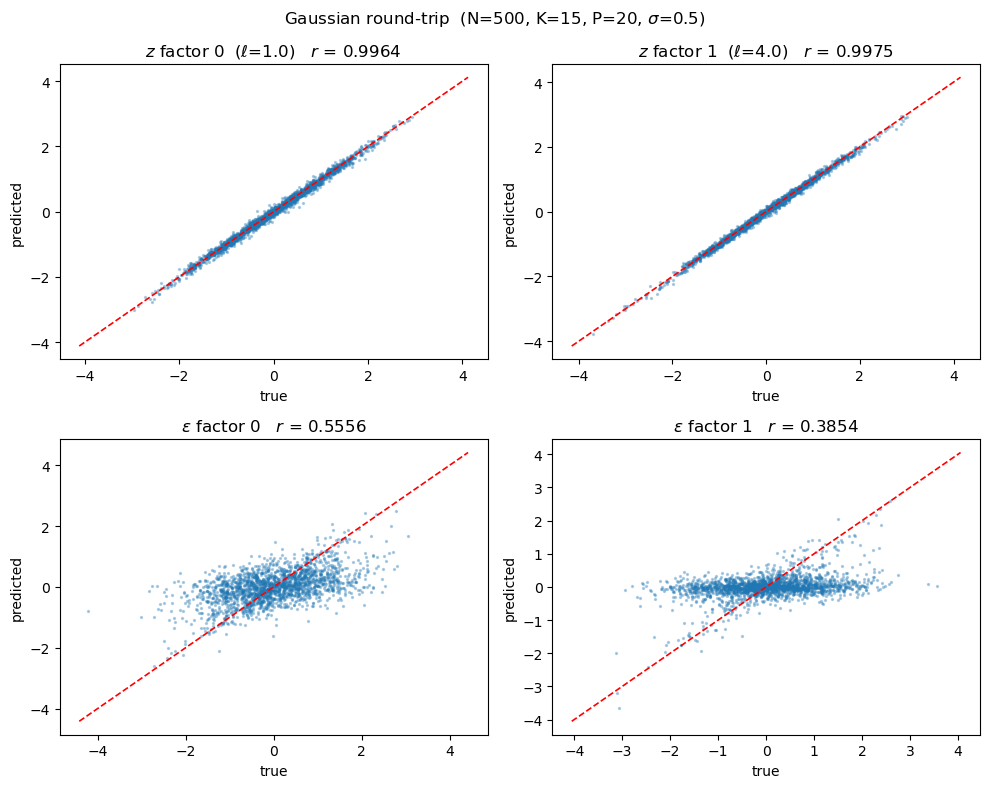

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for k in range(Q):
    zt  = z_true[:,   :, k].reshape(-1).cpu()
    zp  = z_pred[:,   :, k].reshape(-1).cpu()
    et  = eps_true[:, :, k].reshape(-1).cpu()
    ep  = eps_pred[:, :, k].reshape(-1).cpu()
    rz  = torch.corrcoef(torch.stack([zt, zp]))[0,1].item()
    re  = torch.corrcoef(torch.stack([et, ep]))[0,1].item()

    for row, (xt, xp, r, lbl) in enumerate([
            (zt, zp, rz, f'$z$ factor {k}  ($\ell$={ELL[k]})'),
            (et, ep, re, f'$\\varepsilon$ factor {k}')]):
        ax = axes[row, k]
        # subsample for plot clarity
        idx = torch.randperm(len(xt))[:2000]
        ax.scatter(xt[idx], xp[idx], s=2, alpha=0.3)
        lim = max(xt.abs().max(), xp.abs().max()).item()*1.05
        ax.plot([-lim,lim],[-lim,lim],'r--',lw=1.2)
        ax.set_xlabel('true'); ax.set_ylabel('predicted')
        ax.set_title(f'{lbl}   $r$ = {r:.4f}')

fig.suptitle(
    f'Gaussian round-trip  (N={N}, K={K}, P={P}, $\\sigma$={SIGMA})',
    fontsize=12)
fig.tight_layout()


## What this tells us

- **Test 1**: $\varepsilon\to z\to\varepsilon$ is exact to machine precision — the Cholesky
  multiply/solve pair is a perfect bijection.
- **Test 2**: with Gaussian $Y$, the exact posterior mean recovers both $z$ and $\varepsilon$ well.
  Residual error comes entirely from the $\sigma$-noise, not from any approximation in the encoder.

**Implication for Poisson:** `encode_block_gauss` uses $\log(1+y)$ as a proxy for
$\eta = Wz+b$.  That proxy is the approximation error — not the ε↔Z mapping, which is always exact.
Replace the proxy with a proper Poisson Newton MAP (block-level) and the round-trip should be as
clean as Test 2 above.
